# FunnyBirds — Data Analysis
Dataset only (no model). Class balance · concept prevalence · class×concept matrix · species-constancy · candidate part features.

In [1]:
import os, sys, pickle
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

CURATED = Path(os.environ["CURATED_DATA"])
FB = CURATED / "FunnyBirds"; PK = CURATED / "funnybirds_processed"
sys.path.insert(0, str(Path.cwd().parent / "data" / "funnybirds"))  # run from curated/notebooks
import funnybirds_concepts as fbc

parts = fbc.load_parts(FB); names = fbc.concept_names(parts); spans = fbc.group_slices(parts)
nC = len(names); part_of = {j:p for p,(a,b) in spans.items() for j in range(a,b)}
col = {p:c for p,c in zip(spans, plt.cm.tab10.colors)}
load = lambda f: pickle.load(open(PK/f,"rb"))
tr, te = load("train.pkl"), load("test.pkl")
Atr=np.array([r["attribute_label"] for r in tr]); ytr=np.array([r["class_label"] for r in tr])
Ate=np.array([r["attribute_label"] for r in te]); yte=np.array([r["class_label"] for r in te])
print(f"train {len(tr)} / test {len(te)} imgs · {len(set(ytr))} species · {nC} concepts")

train 50000 / test 500 imgs · 50 species · 26 concepts


## 1. Class balance

train/species: 1000 - 1000 | test/species: 10 - 10


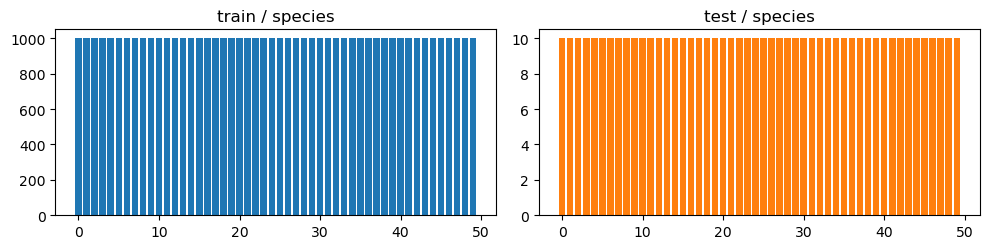

In [2]:
tc=pd.Series(ytr).value_counts().sort_index(); ec=pd.Series(yte).value_counts().sort_index()
print("train/species:",tc.min(),"-",tc.max(),"| test/species:",ec.min(),"-",ec.max())
fig,ax=plt.subplots(1,2,figsize=(10,2.6))
ax[0].bar(tc.index,tc.values); ax[0].set_title("train / species")
ax[1].bar(ec.index,ec.values,color="tab:orange"); ax[1].set_title("test / species"); plt.tight_layout()

## 2. Concept prevalence (by part)

rarest: ['tail_7', 'tail_0', 'tail_4', 'tail_1', 'tail_6']


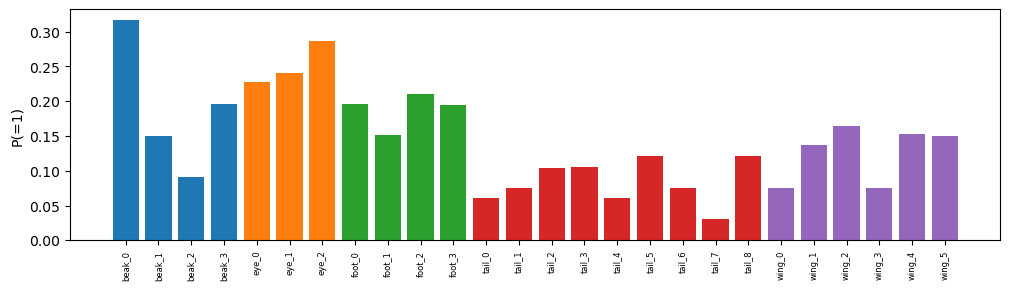

In [3]:
prev=Atr.mean(0)
fig,ax=plt.subplots(figsize=(12,3))
ax.bar(range(nC),prev,color=[col[part_of[j]] for j in range(nC)])
ax.set_xticks(range(nC)); ax.set_xticklabels(names,rotation=90,fontsize=6); ax.set_ylabel("P(=1)")
print("rarest:",[names[i] for i in np.argsort(prev)[:5]])

## 3. Class × concept matrix

cells exactly 0/1: 0.8077 (1.0 = clean species→concept lookup)


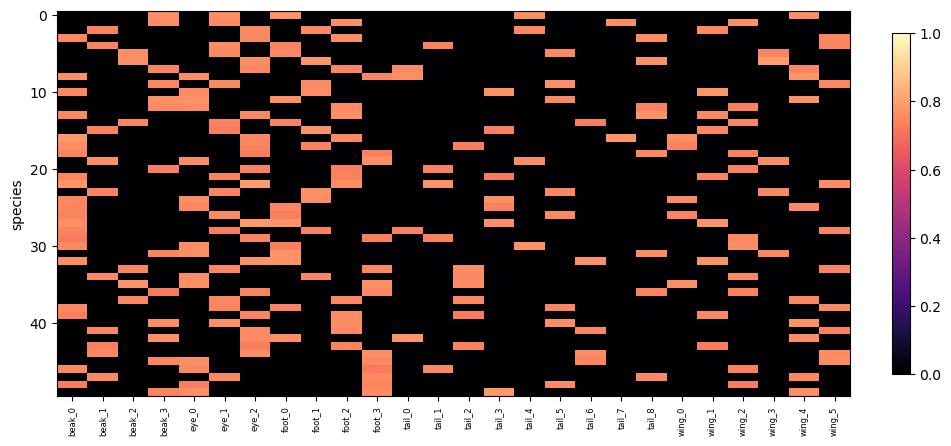

In [4]:
M=pd.DataFrame(Atr).assign(c=ytr).groupby("c").mean().values
print("cells exactly 0/1:",round(float(np.mean((M==0)|(M==1))),4),"(1.0 = clean species→concept lookup)")
fig,ax=plt.subplots(figsize=(11,5)); im=ax.imshow(M,aspect="auto",cmap="magma",vmin=0,vmax=1)
ax.set_xticks(range(nC)); ax.set_xticklabels(names,rotation=90,fontsize=6); ax.set_ylabel("species")
fig.colorbar(im,ax=ax,fraction=0.02)

### 3b. Reconciling §3 (train 0.81) with §4 (test 1.00) — read this
§3 will show ~**0.81** of (species, concept) cells are exactly 0/1 in **train** (so 19%
vary within a species), while §4 shows **1.00** species-constant on **test**. Not a
contradiction, and not a bug:

The FunnyBirds concept label is **per-image part presence** — a part rendered as
`placeholder` (absent) gets label 0 (see `params_to_concept_vector`). The **train** set
contains images with parts removed, so a species' concept varies across its images
(→ 0.81). The **test** images are all "full", so on the evaluation set concept = f(species)
exactly (→ 1.00). The cell below quantifies this and shows the variation is concentrated
in the parts that get removed. **Why it matters:** training *did* contain part-absent→0
examples, so the model could have learned to ground; that it still backwashes on the
deletion test (notebook 02) is therefore emergent, not forced by class-level labels.

In [ ]:
# 3b diagnostic: where does the train within-species variation live?
Mtr = pd.DataFrame(Atr).assign(c=ytr).groupby("c").mean()          # 50 x 26 species means
frac_bin = float(np.mean((Mtr.values==0)|(Mtr.values==1)))
varying = (Mtr>0)&(Mtr<1)                                          # cells that vary within species
print(f"train: {frac_bin:.3f} of (species,concept) cells are exactly 0/1 "
      f"-> {(1-frac_bin)*100:.1f}% vary within a species")
per_part = {p: int(varying.iloc[:, a:b].values.sum()) for p,(a,b) in spans.items()}
print("count of varying (species,concept) cells, by part:", per_part)
# same on test for contrast
Wte = np.array([Ate[yte==c].std(0) for c in np.unique(yte)])
print(f"test: {float(np.mean(Wte==0)):.3f} of cells have within-species std 0 "
      f"(1.00 = every concept constant within species on the eval set)")

## 4. Species-constancy — why the recall gap is a CUB tool, not FunnyBirds
Within-species std of each concept on test. ~0 ⇒ concepts don't vary within a species ⇒ matched-pair recall gap is n=10 quantization noise here (use deletion/swap instead).

In [5]:
within=np.array([Ate[yte==c].std(0) for c in np.unique(yte)])
frac0=float(np.mean(within==0)); nimg=int(min((yte==c).sum() for c in np.unique(yte)))
print(f"(species,concept) with within-species std==0: {frac0:.4f} | mean std {within.mean():.4g} | test imgs/species {nimg}")
print("VERDICT:", "species-constant → recall gap = n=%d noise here; use deletion/swap"%nimg if frac0>0.999
      else "within-species variation exists → recall gap may be testable")

(species,concept) with within-species std==0: 1.0000 | mean std 0 | test imgs/species 10
VERDICT: species-constant → recall gap = n=10 noise here; use deletion/swap


## 5. Part features — candidates to line up against measured backwash
Neutral dataset properties per part (not a conclusion). Compare against per-part backwash from `grounding_deletion.py` (tail retained_frac≈0.31, others≈0).

,part,n_variants,mean_px,median_px,frac_visible
3,tail,9,99.8,17.0,0.635
4,wing,6,689.7,567.0,0.756
0,beak,4,127.3,78.0,0.749
2,foot,4,283.2,232.0,0.757
1,eye,3,111.7,86.0,0.753


Text(0, 0.5, '# variants')

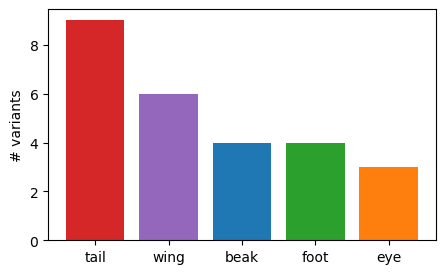

In [6]:
vis_p=CURATED/"funnybirds_visibility.parquet"; vis=pd.read_parquet(vis_p) if vis_p.exists() else None
rows=[]
for p,(a,b) in spans.items():
    r={"part":p,"n_variants":b-a}
    if vis is not None:
        vp=vis[vis.part==p]
        if len(vp): r|={"mean_px":round(float(vp.pixel_count.mean()),1),
                        "median_px":float(vp.pixel_count.median()),
                        "frac_visible":round(float((vp.pixel_count>0).mean()),3)}
    rows.append(r)
prof=pd.DataFrame(rows).sort_values("n_variants",ascending=False); display(prof)
fig,ax=plt.subplots(figsize=(5,3))
ax.bar(prof.part,prof.n_variants,color=[col[p] for p in prof.part]); ax.set_ylabel("# variants")